# BCI Transfer Learning: EEGNet

Ran the preprocessing script before this notebook to get data ready:
```bash
python preprocess.py --mode raw --n_subjects 30
```
Saved data as `processed_data/eegnet/S001_X.npy`, `S001_y.npy`, etc.

In [204]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

import time
from pathlib import Path
from copy import deepcopy
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from eegnet_imp import build_eegnet

In [205]:
import importlib
import eegnet_imp
importlib.reload(eegnet_imp)
from eegnet_imp import build_eegnet, EEGNet_base

In [206]:
# configs for loading / sectioning data and selecting viable subjects

SUBJECT_IDS = list(range(1, 31))  
DATA_DIR= Path('./processed_data/eegnet')
OUTPUT_DIR = Path('./results')
OUTPUT_DIR.mkdir(exist_ok=True)

PRETRAIN_EPOCHS=150
FINETUNE_EPOCHS=50

PRETRAIN_LR = 1e-3
FINETUNE_LR=1e-4

BATCH_SIZE=64    # num epochs processed in one batch
TEST_FRACTION=0.50

# selecting MI literate subjects for further fine-tuning
LITERACY_THRESHOLD= 0.70 
N_LITERATE= 5 # select top-5 performing subjects

# progressively expose pretrained models to more and more data
# of the unseen subject
FINE_TUNE_FRACTIONS = [0.1, 0.25, 0.5]

# set random seeds
np.random.seed(42)
torch.manual_seed(42)

In [207]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## Loading Preprocessed Data / Scaling up

In [208]:
all_data = {}
for sid in SUBJECT_IDS:
    s=str(sid).zfill(3)
    X= np.load(DATA_DIR / f'S{s}_X.npy')        # (n samples, 64, 321)
    y = np.load(DATA_DIR / f'S{s}_y.npy')       # (n samples,)
    
    X = X * 1e6   # linearly scaling up raw voltage data since org values create near-zero logits
    
    all_data[sid] = (X, y)
    print(f'S{s}: X={X.shape}, y={y.shape}, left={y.sum()}, right={(y==0).sum()}')

sample_X = all_data[SUBJECT_IDS[0]][0]
N_CHANNELS = sample_X.shape[1]
N_TIMEPOINTS = sample_X.shape[2]

S001: X=(45, 64, 321), y=(45,), left=23, right=22
S002: X=(45, 64, 321), y=(45,), left=23, right=22
S003: X=(45, 64, 321), y=(45,), left=23, right=22
S004: X=(45, 64, 321), y=(45,), left=23, right=22
S005: X=(45, 64, 321), y=(45,), left=21, right=24
S006: X=(45, 64, 321), y=(45,), left=24, right=21
S007: X=(45, 64, 321), y=(45,), left=23, right=22
S008: X=(45, 64, 321), y=(45,), left=22, right=23
S009: X=(45, 64, 321), y=(45,), left=24, right=21
S010: X=(45, 64, 321), y=(45,), left=24, right=21
S011: X=(45, 64, 321), y=(45,), left=23, right=22
S012: X=(45, 64, 321), y=(45,), left=21, right=24
S013: X=(45, 64, 321), y=(45,), left=23, right=22
S014: X=(45, 64, 321), y=(45,), left=22, right=23
S015: X=(45, 64, 321), y=(45,), left=23, right=22
S016: X=(45, 64, 321), y=(45,), left=22, right=23
S017: X=(45, 64, 321), y=(45,), left=23, right=22
S018: X=(45, 64, 321), y=(45,), left=22, right=23
S019: X=(45, 64, 321), y=(45,), left=23, right=22
S020: X=(45, 64, 321), y=(45,), left=23, right=22


## LOO-Subject Baseline

In [209]:
def split_subject(X, y, test_frac=TEST_FRACTION, seed=42):
    # stratified train/test split for one subject
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_frac, stratify=y, random_state=42)
    # ensure train always gets the larger half
    if len(X_train) < len(X_test):
        X_train, X_test = X_test, X_train
        y_train, y_test = y_test, y_train
    return X_train, y_train, X_test, y_test

def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    # convert npy arrays datatype to pytorch dataloader for training
    X = X[:, np.newaxis, :, :] # had to update this from (N,C,T) to (N,1,C,T) for new EEGNet implementation
    ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def make_subset_loader(X, y, fraction, batch_size=32, seed=42):
    # stratified fractional subset loader for fine-tuning
    _, X_sub, _, y_sub = train_test_split(X, y, test_size=fraction, stratify=y, random_state=seed)
    
    # try:
    #     _, X_sub, _, y_sub = train_test_split(X, y, test_size=fraction, stratify=y, random_state=seed)
    # except ValueError: # in case not enough 
    #     _, X_sub, _, y_sub = train_test_split(X, y, test_size=fraction, random_state=seed)
    return make_loader(X_sub, y_sub, batch_size=batch_size)



def run_epoch(model, loader, optimizer, criterion):
    model.train()
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        criterion(model(X_b), y_b).backward()
        optimizer.step()


@torch.no_grad()
def evaluate(model, loader): # compute accuracy scores
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device) # to gpu
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total += len(y_b)
    return correct / total

In [210]:
def train_model(model,train_loader,val_loader,n_epochs=PRETRAIN_EPOCHS,lr=PRETRAIN_LR, patience=20, progress_report=True):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4) # added weight decay to penalize large wts
    criterion = nn.CrossEntropyLoss()

    # used to get snapshot of best model with best acc
    best_acc = 0
    best_state = deepcopy(model.state_dict())
    
    # also count how many steps we go without improvement for early stoppig
    patience_counter = 0
    
    for epoch in range(1, n_epochs+1):
        run_epoch(model,train_loader, optimizer,criterion)
        val_acc = evaluate(model, val_loader)

        # early stopping based on patience
        if val_acc > best_acc:
            best_acc, best_state = val_acc, deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if progress_report: print(f'    Early stop at epoch {epoch}')
                break
        
        # print validation accuracies every 20 eps until stopping
        if progress_report and epoch%20==0:
            print(f'    Epoch {epoch}: validation acc={val_acc:.3f}')
            
    model.load_state_dict(best_state)
    return model


def finetune_model(pretrained,ft_loader, val_loader,n_epochs=FINETUNE_EPOCHS, lr=FINETUNE_LR, patience=15):
    # start at same pretrained model from saved
    model = deepcopy(pretrained).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(1, n_epochs+1):
        run_epoch(model, ft_loader, optimizer, criterion)
    return model

In [211]:
# model_dir = OUTPUT_DIR / 'models'
# model_dir.mkdir(exist_ok=True)
baseline_csv = OUTPUT_DIR / 'baseline_training.csv'

In [212]:
# check which subjects have already been run
# resumable in case training takes too long / run on cpu
done_records = pd.read_csv(baseline_csv).to_dict('records') if baseline_csv.exists() else []
done_ids = {r['subject_id'] for r in done_records}
print(f'Already done: {sorted(done_ids)}')

Already done: [1, 2, 3]


In [ ]:
# Main LOO-subject loop

for target_id in SUBJECT_IDS:
    # skip subject if we've finished its LOO fold
    if target_id in done_ids:
        continue
        
    t0 = time.time() # to track training time
    print(f'\nTarget: S{str(target_id).zfill(3)}')

    # pool all other subjects (except LOO subject)
    train_ids = [s for s in SUBJECT_IDS if s != target_id]
    X_pool = np.concatenate([all_data[s][0] for s in train_ids]) # (29*45, 64, 321) --> collapse subject-wise
    y_pool = np.concatenate([all_data[s][1] for s in train_ids]) # (29*45,)
    # shuffle so data isn't organized by subject chunks
    perm = np.random.permutation(len(y_pool))
    X_pool, y_pool = X_pool[perm], y_pool[perm] # X = (29*45, 64, 321), y = # (29*45,)

    # 90/10 split for early stopping evals, no effect on grads / wt updates
    n_val = max(1, int(len(y_pool)*0.1))
    train_loader = make_loader(X_pool[n_val:], y_pool[n_val:])
    val_loader = make_loader(X_pool[:n_val], y_pool[:n_val], shuffle=False)

    # 0-shot test: test full target subject data
    X_t, y_t = all_data[target_id]
    test_loader = make_loader(X_t, y_t, shuffle=False)

    # init model and train on all other subjects
    model = build_eegnet(n_channels=N_CHANNELS, n_timepoints=N_TIMEPOINTS) # calling braindecoder implementation 
    model = train_model(model, train_loader, val_loader,progress_report=True)

    # evaluate model on heldout subject data (0-shot)
    acc = evaluate(model,test_loader)
    print(f'  Baseline acc: {acc:.4f}  ({time.time()-t0:.0f}s)') # finish target time
    
    # to keep resumable, save subject by subject run
    done_records.append({'subject_id': target_id, 'baseline_acc': acc, 'n_trials': len(y_t)})
    pd.DataFrame(done_records).to_csv(baseline_csv, index=False)

df_baseline = pd.read_csv(baseline_csv)
print('\nDone!')
print(df_baseline.to_string(index=False))

## Finding MI-BCI-efficient (Top Performing) Subjects

In [213]:
df_baseline = pd.read_csv(OUTPUT_DIR / 'baseline_training.csv')

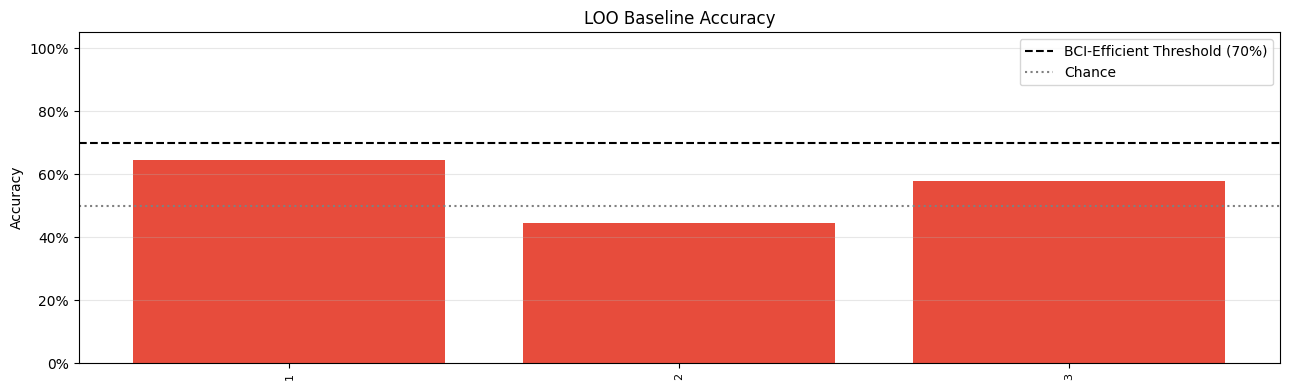

In [214]:
fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#2ecc71' if a >= LITERACY_THRESHOLD else '#e74c3c' for a in df_baseline['baseline_acc']]

ax.bar(range(len(df_baseline)), df_baseline['baseline_acc'], color=colors)
ax.axhline(LITERACY_THRESHOLD, color='k', linestyle='--', label=f'BCI-Efficient Threshold ({LITERACY_THRESHOLD:.0%})')
ax.axhline(0.5, color='gray', linestyle=':', label='Chance')
ax.set_xticks(range(len(df_baseline)))
ax.set_xticklabels(df_baseline['subject_id'].astype(str), rotation=90, fontsize=8)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('LOO Baseline Accuracy'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [215]:
literate_df = df_baseline[df_baseline['baseline_acc']>=LITERACY_THRESHOLD]
literate_df = literate_df.nlargest(N_LITERATE, 'baseline_acc')
if len(literate_df) < N_LITERATE:
    print(f'Not enough subjects above threshold. Using top {N_LITERATE}.')
    literate_df = df_baseline.nlargest(N_LITERATE, 'baseline_acc')

literate_ids = literate_df['subject_id'].tolist()
print('Selected subjects:', literate_ids)
print(literate_df[['subject_id','baseline_acc']].to_string(index=False))

Not enough subjects above threshold. Using top 5.
Selected subjects: [1, 3, 2]
 subject_id  baseline_acc
          1      0.644444
          3      0.577778
          2      0.444444


## Fine-tuning Learning Curves
Skips (subject, alignment) pairs already saved in `finetuning.csv`.</br>
Alignment modes: none only for now. EA/SRM to be added.

In [223]:
ft_csv = OUTPUT_DIR / 'finetuning.csv'
ft_records = pd.read_csv(ft_csv).to_dict('records') if ft_csv.exists() else []
done_ft_keys = {(r['subject_id'], r['alignment']) for r in ft_records}

In [246]:
from alignment_methods import euclidean_alignment, riemannian_alignment, srm_alignment, SRM

# precompute EA and RA for all subjects once
ea_cache = {}
print("EA.")
for sid in SUBJECT_IDS:
    ea_cache[sid] = euclidean_alignment(all_data[sid][0])
    print(f'  S{str(sid).zfill(3)} done')

ra_cache = {}
print("-"*50)
print("RA.")
for sid in SUBJECT_IDS:
    ra_cache[sid] = riemannian_alignment(all_data[sid][0])
    print(f'  S{str(sid).zfill(3)} done')

EA.
  S001 done
  S002 done
  S003 done
  S004 done
  S005 done
  S006 done
  S007 done
  S008 done
  S009 done
  S010 done
  S011 done
  S012 done
  S013 done
  S014 done
  S015 done
  S016 done
  S017 done
  S018 done
  S019 done
  S020 done
  S021 done
  S022 done
  S023 done
  S024 done
  S025 done
  S026 done
  S027 done
  S028 done
  S029 done
  S030 done
--------------------------------------------------
RA.
  S001 done
  S002 done
  S003 done
  S004 done
  S005 done
  S006 done
  S007 done
  S008 done
  S009 done
  S010 done
  S011 done
  S012 done
  S013 done
  S014 done
  S015 done
  S016 done
  S017 done
  S018 done
  S019 done
  S020 done


/Users/ankitainamti/miniforge3/envs/cogs118a/lib/python3.13/site-packages/pyriemann/utils/mean.py:688: UserWarning: Convergence not reached
  warnings.warn("Convergence not reached")


  S021 done
  S022 done
  S023 done
  S024 done
  S025 done
  S026 done
  S027 done
  S028 done
  S029 done
  S030 done


In [247]:
ALIGNMENT_MODES = ['none', 'ea', 'ra', 'srm']

def apply_alignment(mode, X_train_list, train_ids, X_target_train, X_target_test, target_id):
    # alignment to be applied to three sets of X
        # X_train_list --> LIST of len=29, each element is npy array of shape (45 trials, 64 channnels, 321 timepoints)
        # X_target_train --> npy array of shape (23,64,321) used for fine-tuning on unseen subject
        # X_target_test --> npy arr of shape (22,64,321) used for evaluation of FT models on unseen subject
    
    if mode == 'none':
        return X_train_list, X_target_train, X_target_test

    elif mode == 'ea':
        # apply euclidean alignment separately to each dataset / per subject
        X_train_list_ea = [ea_cache[sid] for sid in train_ids]
        X_target_train_ea = euclidean_alignment(X_target_train)
        X_target_test_ea  = euclidean_alignment(X_target_test)

        return X_train_list_ea, X_target_train_ea, X_target_test_ea

    elif mode == 'ra':
        # apply riemannian alignment separately to each dataset / per subject
        X_train_list_ra = [ra_cache[sid] for sid in train_ids]
        X_target_train_ra = riemannian_alignment(X_target_train)
        X_target_test_ra  = riemannian_alignment(X_target_test)

        return X_train_list_ra, X_target_train_ra, X_target_test_ra
        
    elif mode == 'srm':
        n_features = 20
        n_ch = X_target_train.shape[1]
        n_times = X_target_train.shape[2]

        # 1. Flatten to 2D
        train_cont = [sub.transpose(1, 0, 2).reshape(n_ch, -1) for sub in X_train_list]
        target_tr_cont = X_target_train.transpose(1, 0, 2).reshape(n_ch, -1)
        target_te_cont = X_target_test.transpose(1, 0, 2).reshape(n_ch, -1)

        # 2. Truncate source subjects only (target is excluded from fit)
        min_len = min(d.shape[1] for d in train_cont)
        train_cont_trunc = [d[:, :min_len] for d in train_cont]

        # 3. Fit SRM on source subjects only
        all_aligned_cont, srm = srm_alignment(train_cont_trunc, n_features=n_features)

        # 4. Project target train + test as new subject
        X_target_tr_shared, W_target = srm.transform_new(target_tr_cont)
        X_target_te_shared = W_target.T @ target_te_cont

        # 5. Re-epoch to 3D
        n_trials_trunc = min_len // n_times

        def reshape_back(data_2d, n_trials):
            return data_2d.reshape(n_features, n_trials, n_times).transpose(1, 0, 2)

        X_train_final = [reshape_back(sub, n_trials_trunc) for sub in all_aligned_cont]
        X_target_tr_final = reshape_back(X_target_tr_shared, X_target_train.shape[0])
        X_target_te_final = reshape_back(X_target_te_shared, X_target_test.shape[0])

        return X_train_final, X_target_tr_final, X_target_te_final
    else:
        print("Invalid mode.")

In [248]:
# Main fine-tuning loop
for target_id in literate_ids: # only over the top-performers of MI task
    print(f'\n{"-"*50}\nTarget: S{str(target_id).zfill(3)}')

    
    X_target, y_target = all_data[target_id]
    X_tr, y_tr, X_te, y_te = split_subject(X_target, y_target)
    train_ids= [s for s in SUBJECT_IDS if s!= target_id]
    X_train_list = [all_data[s][0] for s in train_ids]
    y_train_list = [all_data[s][1] for s in train_ids]

    for mode in ALIGNMENT_MODES:
        if (target_id, mode) in done_ft_keys:
            print(f'  [{mode}] already done, skipping')
            continue
        print(f'  Alignment: {mode}')

        # apply alignment (if needed)
        X_tr_aligned, X_ft_aligned, X_te_aligned = apply_alignment(mode, X_train_list, train_ids, X_tr, X_te, target_id)

        # pretrain (mainly for EA/RA/SRM since earlier pretrained models not exposed to aligned data)
        # for simplicity, I'm redoing the pretraining for all scenarios
        
        n_trials_per_source = X_tr_aligned[0].shape[0]
        X_pool = np.concatenate(X_tr_aligned)
        y_pool = np.concatenate([y[:n_trials_per_source] for y in y_train_list])

        # shuffle training data to prevent subject-wise clumping
        perm = np.random.permutation(len(y_pool)) 
        X_pool, y_pool = X_pool[perm], y_pool[perm] # X = (29*45, 64, 321), y = # (29*45,)
        n_val = max(1, int(len(y_pool)*0.1))

        n_ch = X_pool.shape[1]
        n_tp = X_pool.shape[2]
        
        pretrained = build_eegnet(n_channels=n_ch, n_timepoints=n_tp)
        pretrained = train_model(
            pretrained,
            make_loader(X_pool[n_val:],y_pool[n_val:]),
            make_loader(X_pool[:n_val], y_pool[:n_val], shuffle=False),
            progress_report=False
        )

        # load target subject (unseen) for testing
        test_loader = make_loader(X_te_aligned, y_te, shuffle=False)

        # 0-shot
        zero_acc = evaluate(pretrained, test_loader)
        print(f'    0%  --> {zero_acc:.4f}')
        ft_records.append(dict(subject_id=target_id, alignment=mode,
                               ft_fraction=0.0, test_acc=zero_acc, n_ft_trials=0))

        # fine-tune at each fraction for progressie exposure to unseen subject
        for frac in FINE_TUNE_FRACTIONS:
            ft_loader = make_subset_loader(X_ft_aligned, y_tr, fraction=frac)
            n_ft = int(np.ceil(len(y_tr) * frac))
            # fine-tune on fraction of target subject training data
            ft_model = finetune_model(pretrained, ft_loader, test_loader)
            
            acc = evaluate(ft_model, test_loader)
            print(f'    {int(frac*100):3d}% ({n_ft} trials) --> {acc:.4f}')
            ft_records.append(dict(subject_id=target_id, alignment=mode,ft_fraction=frac, test_acc=acc, n_ft_trials=n_ft))

        done_ft_keys.add((target_id,mode))
        pd.DataFrame(ft_records).to_csv(ft_csv, index=False)


--------------------------------------------------
Target: S001
  [none] already done, skipping
  [ea] already done, skipping
  [ra] already done, skipping
  Alignment: srm
    0%  --> 0.5000
     10% (3 trials) --> 0.5000
     25% (6 trials) --> 0.4545
     50% (12 trials) --> 0.3636

--------------------------------------------------
Target: S003
  [none] already done, skipping
  [ea] already done, skipping
  [ra] already done, skipping
  Alignment: srm
    0%  --> 0.5000
     10% (3 trials) --> 0.5000
     25% (6 trials) --> 0.4545
     50% (12 trials) --> 0.5000

--------------------------------------------------
Target: S002
  [none] already done, skipping
  [ea] already done, skipping
  [ra] already done, skipping
  Alignment: srm
    0%  --> 0.3636
     10% (3 trials) --> 0.5455
     25% (6 trials) --> 0.5455
     50% (12 trials) --> 0.5455


## Plots

In [249]:
df_ft = pd.read_csv(OUTPUT_DIR / 'finetuning.csv')

COLORS = {'none': '#4C72B0', 'ea': '#DD8452', 'srm': '#55A868'}
LABELS = {'none': 'No Alignment', 'ea': 'Euclidean Alignment', 'ra': "Riemannian Alignment", 'srm': 'SRM'}
all_fracs = [0.0]+FINE_TUNE_FRACTIONS

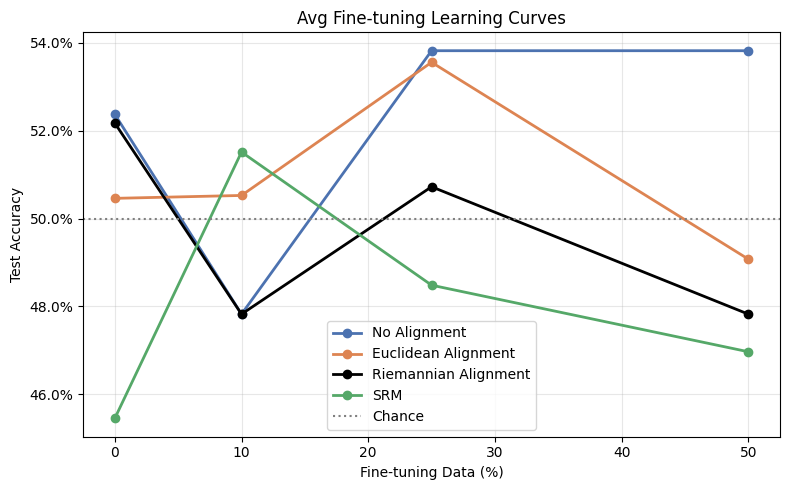

In [250]:
# averaged learning curves
fig, ax = plt.subplots(figsize=(8, 5))
for mode in df_ft['alignment'].unique():
    sub = df_ft[df_ft['alignment'] == mode]
    mean = sub.groupby('ft_fraction')['test_acc'].mean()
    xs = mean.index.values * 100
    c = COLORS.get(mode, 'black')
    ax.plot(xs, mean.values, 'o-', color=c, label=LABELS.get(mode, mode), lw=2)
ax.axhline(0.5, color='gray', linestyle=':', label='Chance')
ax.set_xlabel('Fine-tuning Data (%)'); ax.set_ylabel('Test Accuracy')
ax.set_title('Avg Fine-tuning Learning Curves')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

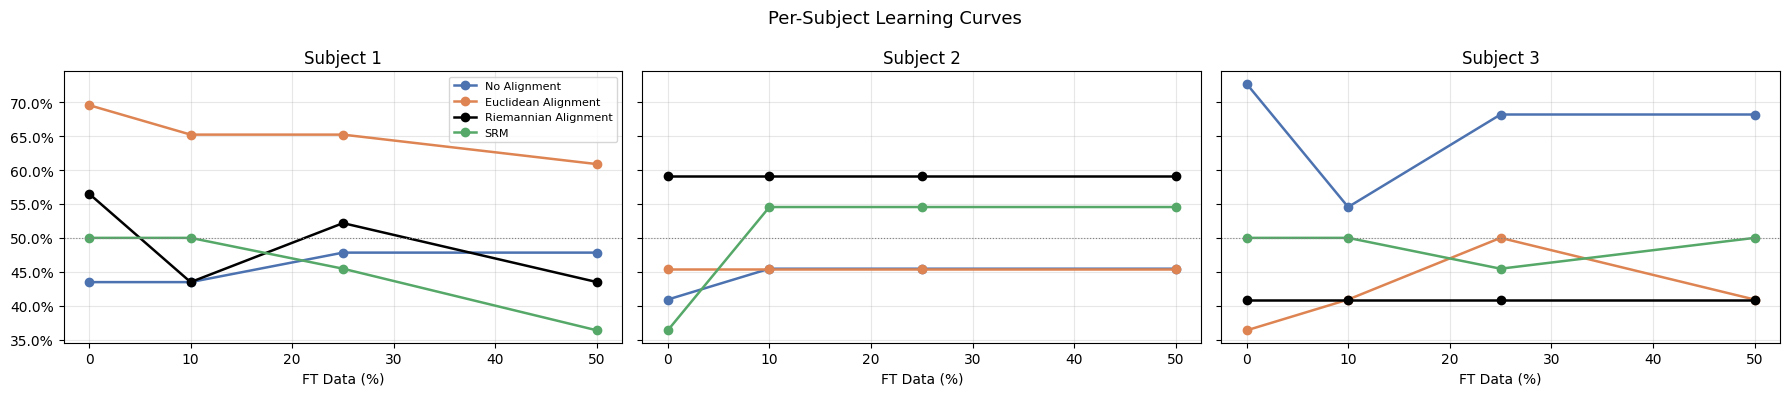

In [251]:
# per-subject subplots
subjects = sorted(df_ft['subject_id'].unique())
ncols = min(len(subjects), 3)
nrows = -(-len(subjects) // ncols)  # ceiling div
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)
axes = np.array(axes).flatten()
for i, sid in enumerate(subjects):
    ax = axes[i]
    for mode in df_ft['alignment'].unique():
        sub  = df_ft[(df_ft['subject_id']==sid) & (df_ft['alignment']==mode)]
        accs = [sub[sub['ft_fraction']==f]['test_acc'].values[0]
                if len(sub[sub['ft_fraction']==f]) else np.nan for f in all_fracs]
        ax.plot([f*100 for f in all_fracs], accs, 'o-',
                color=COLORS.get(mode,'black'), label=LABELS.get(mode,mode), lw=1.8)
    ax.axhline(0.5, color='gray', linestyle=':', lw=0.8)
    ax.set_title(f'Subject {sid}'); ax.set_xlabel('FT Data (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(alpha=0.3)
    if i == 0: ax.legend(fontsize=8)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('Per-Subject Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()